# TagLM

使用hagging face提供的BERT模型作为BiLM嵌入。

## 对齐

真实的模型（如 BERT）会把一个长单词拆成多个子词（Subwords）。但我们的基线序列标注模型（以及我们写的 CharCNN）是**基于完整单词（Word-level）**的。如果 BERT 把 5 个单词拆成了 7 个 Token，特征维度就拼不上了！为了解决这个问题，业界标准的做法是：将预训练模型输出的第一个子词的向量，作为整个单词的代表向量。

## 第一步：加载真实的预训练模型并编写对齐包装器
我们将使用 Hugging Face 加载一个轻量级的 BERT（以节省你本地运行的内存），并编写一个 RealBiLM 包装器来处理恶心的子词对齐问题。

In [1]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

# 随机种子，保证每次运行结果一致
torch.manual_seed(42)

# === 定义超参数 ===
# 词汇表大小 (假设)
WORD_VOCAB_SIZE = 5000  
CHAR_VOCAB_SIZE = 60    
TAGSET_SIZE = 5         # 比如: O, B-PER, I-PER, B-LOC, I-LOC

# 维度设置
WORD_EMB_DIM = 100      # 静态词向量维度
CHAR_EMB_DIM = 30       # 字符嵌入维度
CHAR_CNN_OUT = 50       # 字符CNN输出维度 (每个词的字符级特征长度)
LM_HIDDEN_DIM = 256     # 语言模型单向LSTM的隐藏层维度
TAGGER_HIDDEN_DIM = 200 # 最终序列标注BiLSTM的隐藏层维度

# 1. 加载真实的 Tokenizer 和预训练语言模型 (这里使用 tiny-bert 加快运行速度)
# 你完全可以把它替换成 "bert-base-cased"
MODEL_NAME = "prajjwal1/bert-tiny" 
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
pretrained_bert = AutoModel.from_pretrained(MODEL_NAME)

class BiLM(nn.Module):
    def __init__(self, pretrained_model):
        super(BiLM, self).__init__()
        self.lm = pretrained_model
        # 获取真实模型的输出维度 (bert-tiny 是 128, bert-base 是 768)
        self.hidden_dim = self.lm.config.hidden_size 
        
        # 冻结真实模型的参数 (TagLM 的精髓)
        for param in self.lm.parameters():
            param.requires_grad = False

    def forward(self, batch_sentences):
        """
        batch_sentences: List[List[str]] 例如 [["I", "love", "machine", "unlearning"]]
        """
        device = next(self.lm.parameters()).device
        batch_size = len(batch_sentences)
        max_word_len = max(len(s) for s in batch_sentences)
        
        # 存储对齐后的单词级别向量
        aligned_embeddings = torch.zeros(batch_size, max_word_len, self.hidden_dim).to(device)
        
        # 使用 Tokenizer 处理，设置 is_split_into_words=True 告诉它我们已经按空格分好词了
        encoded = tokenizer(batch_sentences, is_split_into_words=True, 
                            padding=True, truncation=True, return_tensors="pt").to(device)
        
        with torch.no_grad():
            # 获取 BERT 的输出
            outputs = self.lm(**encoded)
            # last_hidden_state shape: [batch, subword_seq_len, hidden_dim]
            hidden_states = outputs.last_hidden_state 
            
        # === 核心逻辑：子词对齐到单词 ===
        for batch_idx in range(batch_size):
            # word_ids 记录了每个子词对应原句中哪个单词的索引
            # 比如 [None, 0, 1, 2, 2, 2, 3, None] (None代表[CLS]或[SEP]，2被拆成了3个子词)
            word_ids = encoded.word_ids(batch_index=batch_idx)
            
            for word_idx in range(len(batch_sentences[batch_idx])):
                try:
                    # 找到该单词对应的第一个子词的位置
                    first_subword_idx = word_ids.index(word_idx)
                    # 提取该子词的向量作为整个单词的特征
                    aligned_embeddings[batch_idx, word_idx, :] = hidden_states[batch_idx, first_subword_idx, :]
                except ValueError:
                    # 如果单词因为超长被截断，跳过
                    pass
                    
        return aligned_embeddings

# 实例化并测试我们的真实特征提取器
real_bilm = BiLM(pretrained_bert)
test_sentences = [["machine", "unlearning", "is", "cool"], ["AI", "rocks"]]
lm_features = real_bilm(test_sentences)

print("真实预训练模型特征提取成功！")
print("特征维度:", lm_features.shape) # 期望输出: [2, 4, 128] (batch=2, max_words=4, hidden=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


真实预训练模型特征提取成功！
特征维度: torch.Size([2, 4, 128])


## 第二步：构建字符级编码器 (Character CNN),将真实特征融合进 TagLM 架构



In [2]:
class CharCNN(nn.Module):
    def __init__(self, char_vocab_size, char_emb_dim, out_channels, kernel_size=3):
        super(CharCNN, self).__init__()
        self.char_emb = nn.Embedding(char_vocab_size, char_emb_dim, padding_idx=0)
        # 1D 卷积提取字符 n-gram 特征
        self.conv1d = nn.Conv1d(in_channels=char_emb_dim, 
                                out_channels=out_channels, 
                                kernel_size=kernel_size, 
                                padding=kernel_size//2)
        
    def forward(self, char_inputs):
        # char_inputs shape: (batch_size, seq_len, max_word_len)
        batch_size, seq_len, max_word_len = char_inputs.size()
        
        # 将 batch 和 seq_len 合并，因为我们是对每个单词独立做 CNN
        char_inputs = char_inputs.view(batch_size * seq_len, max_word_len)
        
        # shape: (batch*seq_len, max_word_len, char_emb_dim)
        embeds = self.char_emb(char_inputs) 
        
        # Conv1d 期待的输入 shape 是 (batch, channels, length)，所以要转置
        embeds = embeds.transpose(1, 2) 
        
        # 卷积 + ReLU -> shape: (batch*seq_len, out_channels, max_word_len)
        conv_out = torch.relu(self.conv1d(embeds))
        
        # 对单词长度维度进行全局最大池化 (Global Max Pooling)
        # shape: (batch*seq_len, out_channels, 1)
        pooled = torch.max(conv_out, dim=2)[0] 
        
        # 恢复 batch 和 seq_len 维度
        # shape: (batch_size, seq_len, out_channels)
        return pooled.view(batch_size, seq_len, -1)

# 测试一下 CharCNN
dummy_chars = torch.randint(1, CHAR_VOCAB_SIZE, (2, 5, 10)) # batch=2, seq_len=5, word_len=10
char_cnn = CharCNN(CHAR_VOCAB_SIZE, CHAR_EMB_DIM, CHAR_CNN_OUT)
print("CharCNN 输出维度:", char_cnn(dummy_chars).shape) # 期望: [2, 5, 50]

CharCNN 输出维度: torch.Size([2, 5, 50])


In [3]:
class TagLM(nn.Module):
    def __init__(self, word_vocab_size, char_vocab_size, tagset_size,
                 word_emb_dim, char_emb_dim, char_cnn_out, tagger_hidden_dim, 
                 real_bilm):
        super(TagLM, self).__init__()
        
        self.word_emb = nn.Embedding(word_vocab_size, word_emb_dim)
        self.char_encoder = CharCNN(char_vocab_size, char_emb_dim, char_cnn_out)
        
        # 注入真实的预训练模型
        self.bilm = real_bilm
        lm_hidden_dim = self.bilm.hidden_dim # 自动获取真实模型的维度
        
        # 拼接维度: 静态词向量 + 字符CNN + 真实预训练模型特征
        combined_dim = word_emb_dim + char_cnn_out + lm_hidden_dim
        
        self.tagger_bilstm = nn.LSTM(combined_dim, tagger_hidden_dim // 2,
                                     num_layers=1, bidirectional=True, batch_first=True)
        self.hidden2tag = nn.Linear(tagger_hidden_dim, tagset_size)
        
    def forward(self, text_sentences, word_ids_tensor, char_ids_tensor):
        # 1. 静态词向量 [batch, seq_len, word_emb_dim]
        word_embeds = self.word_emb(word_ids_tensor)
        
        # 2. 字符级特征 [batch, seq_len, char_cnn_out]
        char_embeds = self.char_encoder(char_ids_tensor)
        
        # 3. 获取真实的预训练特征！ [batch, seq_len, lm_hidden_dim]
        # 注意这里传入的是原生的文本列表
        lm_embeds = self.bilm(text_sentences)
        
        # 确保序列长度对齐 (以防 tensor 和 text 的 padding 长度不一致)
        seq_len = word_ids_tensor.size(1)
        lm_embeds = lm_embeds[:, :seq_len, :]
        
        # 4. 终极融合！
        combined_features = torch.cat([word_embeds, char_embeds, lm_embeds], dim=2)
        
        lstm_out, _ = self.tagger_bilstm(combined_features)
        tag_space = self.hidden2tag(lstm_out)
        
        return tag_space

# 初始化真实架构
real_model = TagLM(
    word_vocab_size=5000, char_vocab_size=60, tagset_size=5,
    word_emb_dim=100, char_emb_dim=30, char_cnn_out=50, tagger_hidden_dim=200,
    real_bilm=real_bilm
)
print("注入真实预训练模型的 TagLM 构建完毕！")

注入真实预训练模型的 TagLM 构建完毕！


### 第三步：使用当前数据集运行数据流
这里不再使用随机模拟输入，直接从当前评估所用的数据集 `OpenMed/drugprot-parquet` 构建一个小批次，送入模型前向计算。

Step 1/20, loss=0.6415
Step 5/20, loss=0.6595
Step 10/20, loss=0.5050
Step 15/20, loss=0.6151
Step 20/20, loss=0.4675

数据集: OpenMed/drugprot-parquet
训练完成: 20 steps
batch_size: 8, 滑动窗口: 5
初始loss: 0.6415, 最终loss: 0.4675


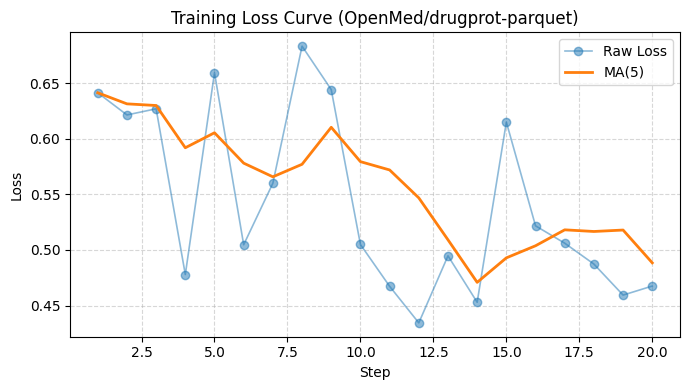

In [16]:
from datasets import load_dataset
import re
import torch.nn as nn
import matplotlib.pyplot as plt

# 使用当前数据集（与评估一致）进行多步训练
train_ds = load_dataset("OpenMed/drugprot-parquet", split="train", streaming=False)

batch_size = 8
max_tokens_per_sample = 64
max_char_len = 10
num_steps = 20
learning_rate = 1e-3
print_every = 5
ma_window = 5  # 滑动平均窗口

def simple_tokenize_with_offsets(text):
    tokens, offsets = [], []
    for m in re.finditer(r"\S+", text):
        tokens.append(m.group(0))
        offsets.append((m.start(), m.end()))
    return tokens, offsets

def map_entity_type_to_bio_ids(entity_type):
    et = str(entity_type).upper()
    if "GENE" in et:
        return 1, 2  # B-PER, I-PER
    if "CHEMICAL" in et:
        return 3, 4  # B-LOC, I-LOC
    return 1, 2

def spans_to_bio_ids(tokens, offsets, entities):
    labels = [0] * len(tokens)  # O
    for ent in entities:
        start = int(ent.get("start", -1))
        end = int(ent.get("end", -1))
        if start < 0 or end <= start:
            continue

        covered = []
        for idx, (ts, te) in enumerate(offsets):
            if not (te <= start or ts >= end):
                covered.append(idx)

        if not covered:
            continue

        b_id, i_id = map_entity_type_to_bio_ids(ent.get("type", ""))
        labels[covered[0]] = b_id
        for idx in covered[1:]:
            labels[idx] = i_id
    return labels

def build_batch_from_indices(dataset, indices):
    text_batch = []
    label_batch = []

    for idx in indices:
        ex = dataset[int(idx)]
        text = ex.get("text", "")
        entities = ex.get("entities", [])

        tokens, offsets = simple_tokenize_with_offsets(text)
        tokens = tokens[:max_tokens_per_sample]
        offsets = offsets[:max_tokens_per_sample]

        if not tokens:
            tokens = ["<PAD>"]
            offsets = [(0, 1)]
            entities = []

        labels = spans_to_bio_ids(tokens, offsets, entities)
        labels = labels[:len(tokens)]

        text_batch.append(tokens)
        label_batch.append(labels)

    seq_len = max(len(x) for x in text_batch)
    bsz = len(text_batch)

    word_ids = torch.zeros((bsz, seq_len), dtype=torch.long)
    char_ids = torch.zeros((bsz, seq_len, max_char_len), dtype=torch.long)
    label_ids = torch.full((bsz, seq_len), fill_value=-100, dtype=torch.long)  # ignore_index

    for i, tokens in enumerate(text_batch):
        for j, tok in enumerate(tokens):
            word_ids[i, j] = (abs(hash(tok.lower())) % 4999) + 1
            for k, ch in enumerate(tok[:max_char_len]):
                char_ids[i, j, k] = (ord(ch) % 59) + 1
            label_ids[i, j] = label_batch[i][j]

    return text_batch, word_ids, char_ids, label_ids

def moving_average(values, window):
    ma = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        ma.append(sum(values[start:i + 1]) / (i - start + 1))
    return ma

# 优化器和损失函数
optimizer = torch.optim.Adam(
    [p for p in real_model.parameters() if p.requires_grad],
    lr=learning_rate
)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

real_model.train()
loss_history = []
dataset_size = len(train_ds)

# 随机打乱索引并按 batch_size 取样
shuffled_indices = torch.randperm(dataset_size).tolist()
cursor = 0

for step in range(num_steps):
    if cursor + batch_size > dataset_size:
        shuffled_indices = torch.randperm(dataset_size).tolist()
        cursor = 0

    indices = shuffled_indices[cursor: cursor + batch_size]
    cursor += batch_size

    text_batch, word_ids, char_ids, label_ids = build_batch_from_indices(train_ds, indices)

    optimizer.zero_grad()
    logits = real_model(text_batch, word_ids, char_ids)  # [B, L, C]
    loss = criterion(logits.view(-1, TAGSET_SIZE), label_ids.view(-1))
    loss.backward()
    optimizer.step()

    loss_value = float(loss.item())
    loss_history.append(loss_value)

    if (step + 1) % print_every == 0 or step == 0:
        print(f"Step {step + 1}/{num_steps}, loss={loss_value:.4f}")

loss_ma = moving_average(loss_history, ma_window)

print("\n数据集: OpenMed/drugprot-parquet")
print(f"训练完成: {num_steps} steps")
print(f"batch_size: {batch_size}, 滑动窗口: {ma_window}")
print(f"初始loss: {loss_history[0]:.4f}, 最终loss: {loss_history[-1]:.4f}")

# loss 曲线可视化（原始 + 滑动平均）
plt.figure(figsize=(7, 4))
steps = list(range(1, num_steps + 1))
plt.plot(steps, loss_history, marker='o', linewidth=1.2, alpha=0.5, label='Raw Loss')
plt.plot(steps, loss_ma, linewidth=2.0, label=f'MA({ma_window})')
plt.title("Training Loss Curve (OpenMed/drugprot-parquet)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## 评估

使用`from sklearn.metrics import classification_report`

### 第一步：定义标签映射与预测函数
我们需要将模型输出的数字 ID 转换回人类可读的标签（如 B-PER, O），并编写一个前向推理函数。

In [17]:
from sklearn.metrics import classification_report

# 1. 定义标签映射 (与之前的 TAGSET_SIZE = 5 对应)
id2tag = {
    0: 'O',       # 其它 (Outside)
    1: 'B-PER',   # 人名开始
    2: 'I-PER',   # 人名内部
    3: 'B-LOC',   # 地名开始
    4: 'I-LOC'    # 地名内部
}

def predict_tags(model, text_batch, word_ids, char_ids, true_lengths):
    """
    模型预测函数
    :param true_lengths: 每个句子的真实长度（用于剔除 Padding）
    """
    model.eval() # 切换到评估模式 (关闭 Dropout 等)
    with torch.no_grad():
        # 获取模型输出的 logits，shape: [batch_size, seq_len, tagset_size]
        logits = model(text_batch, word_ids, char_ids)
        
        # 在 tagset_size 维度取最大值的索引，shape: [batch_size, seq_len]
        predictions = torch.argmax(logits, dim=-1)
        
    pred_tags = []
    # 遍历批次中的每一句话
    for i in range(len(text_batch)):
        length = true_lengths[i]
        # 截断 Padding 部分，只保留真实长度的预测结果
        valid_preds = predictions[i][:length].cpu().numpy()
        # 转换为字符串标签
        pred_tags.append([id2tag[idx] for idx in valid_preds])
        
    return pred_tags

### 第二步：使用 Hugging Face 数据集进行评估（非流式）
这里改为使用 `OpenMed/drugprot-parquet`（非流式加载）。该数据集提供 `text + entities(span)`，因此先将字符级实体区间对齐到 token，再转换为 BIO 标签，最后接入当前 TagLM 的评估流程。

In [18]:
from datasets import load_dataset
import torch
import re

# === 1. 从 Hugging Face 加载 OpenMed/drugprot-parquet（非流式） ===
hf_ds = load_dataset(
    "OpenMed/drugprot-parquet",
    split="train",
    streaming=False,
 )

num_samples = 64
max_tokens_per_sample = 128  # 避免超过 BERT 最大长度(512)
examples = hf_ds.select(range(min(num_samples, len(hf_ds))))

# 当前 id2tag: 0:O, 1:B-PER, 2:I-PER, 3:B-LOC, 4:I-LOC
# 这里做一个任务对齐映射：
# - GENE* -> PER 通道（1/2）
# - CHEMICAL -> LOC 通道（3/4）
def map_entity_type_to_bio_ids(entity_type):
    et = str(entity_type).upper()
    if "GENE" in et:
        return 1, 2
    if "CHEMICAL" in et:
        return 3, 4
    # 其他类型折叠到 PER 通道
    return 1, 2

def tokenize_with_offsets(text):
    """按非空白切词，并返回 (tokens, offsets)。offset 为 [start, end)"""
    tokens, offsets = [], []
    for m in re.finditer(r"\S+", text):
        tokens.append(m.group(0))
        offsets.append((m.start(), m.end()))
    return tokens, offsets

def spans_to_bio_ids(tokens, offsets, entities):
    labels = [0] * len(tokens)
    for ent in entities:
        start = int(ent.get("start", -1))
        end = int(ent.get("end", -1))
        if start < 0 or end <= start:
            continue

        covered = []
        for idx, (ts, te) in enumerate(offsets):
            # token 与实体 span 有交集
            if not (te <= start or ts >= end):
                covered.append(idx)

        if not covered:
            continue

        b_id, i_id = map_entity_type_to_bio_ids(ent.get("type", ""))
        labels[covered[0]] = b_id
        for idx in covered[1:]:
            labels[idx] = i_id
    return labels

val_texts = []
true_tag_ids = []
val_lengths = []

for ex in examples:
    text = ex.get("text")
    entities = ex.get("entities", [])

    if not text:
        continue

    tokens, offsets = tokenize_with_offsets(text)
    if not tokens:
        continue

    bio_ids = spans_to_bio_ids(tokens, offsets, entities)

    # 裁剪过长样本，避免 BERT 序列过长报错
    tokens = tokens[:max_tokens_per_sample]
    bio_ids = bio_ids[:max_tokens_per_sample]

    val_texts.append(tokens)
    true_tag_ids.append(bio_ids)
    val_lengths.append(len(tokens))

if not val_texts:
    raise RuntimeError("未构建出可用样本，请检查数据集字段是否变化。")

# === 2. 构建 word_ids / char_ids（与当前示例模型接口对齐） ===
batch_size_val = len(val_texts)
seq_len_val = max(val_lengths)
max_char_len_val = 10

val_word_ids = torch.zeros((batch_size_val, seq_len_val), dtype=torch.long)
val_char_ids = torch.zeros((batch_size_val, seq_len_val, max_char_len_val), dtype=torch.long)

for i, tokens in enumerate(val_texts):
    for j, tok in enumerate(tokens):
        val_word_ids[i, j] = (abs(hash(tok.lower())) % 4999) + 1
        for k, ch in enumerate(tok[:max_char_len_val]):
            val_char_ids[i, j, k] = (ord(ch) % 59) + 1

# 转换为评估用字符串标签（截断到真实长度）
true_tags = []
for i, length in enumerate(val_lengths):
    true_tags.append([id2tag[idx] for idx in true_tag_ids[i][:length]])

# === 3. 运行预测 ===
predicted_tags = predict_tags(real_model, val_texts, val_word_ids, val_char_ids, val_lengths)

# === 4. 使用 sklearn 评估 ===
flat_true_tags = [tag for sentence in true_tags for tag in sentence]
flat_pred_tags = [tag for sentence in predicted_tags for tag in sentence]

print(f"评估样本数: {batch_size_val}")
print(f"每条样本最多词数: {max_tokens_per_sample}")
print("数据集: OpenMed/drugprot-parquet (train split, non-streaming)")
print("=== 分类评估报告 (Classification Report) ===")
print(classification_report(flat_true_tags, flat_pred_tags, zero_division=0))

评估样本数: 64
每条样本最多词数: 128
数据集: OpenMed/drugprot-parquet (train split, non-streaming)
=== 分类评估报告 (Classification Report) ===
              precision    recall  f1-score   support

       B-LOC       0.00      0.00      0.00       393
       B-PER       0.00      0.00      0.00       432
       I-LOC       0.00      0.00      0.00        54
       I-PER       0.00      0.00      0.00       265
           O       0.86      1.00      0.92      6918

    accuracy                           0.86      8062
   macro avg       0.17      0.20      0.18      8062
weighted avg       0.74      0.86      0.79      8062

